# IN5437 — Assignment 1
## Question 3: Custom Histogram Equalization

**Name:** Benjamine  
**Index:** 258762A

Write a custom function to equalize the histogram of an image, then apply it to the runway image.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read the runway image in grayscale
q3_im = cv.imread('../images/runway.png', cv.IMREAD_GRAYSCALE)
assert q3_im is not None, "File could not be read. Check the path."
print('Shape:', q3_im.shape, '| Min:', q3_im.min(), '| Max:', q3_im.max(), '| Mean:', round(float(q3_im.mean()), 2))

Shape: (769, 765) | Min: 0 | Max: 255 | Mean: 197.12


### Custom histogram equalization function

Implements the formula step by step:
1. Compute histogram
2. Compute CDF (cumulative sum)
3. Scale CDF to [0, 255] → this becomes the LUT
4. Apply LUT to the image

In [3]:
def equalize_histogram(image):
    """
    Custom histogram equalization for an 8-bit grayscale image.
    Implements s_k = round( (L-1) / (M*N) * sum(n_j for j=0..k) )
    """
    L = 256                      # number of intensity levels (8-bit)
    M, N = image.shape           # image dimensions
    total_pixels = M * N

    # Step 1: Compute histogram (count of pixels at each intensity)
    hist = np.zeros(L, dtype=np.int64)
    for k in range(L):
        hist[k] = np.sum(image == k)

    # Step 2: Compute CDF (cumulative sum of histogram)
    cdf = np.cumsum(hist)

    # Step 3: Scale CDF to [0, 255] — this is our LUT
    t = np.round((L - 1) / total_pixels * cdf).astype(np.uint8)

    # Step 4: Apply LUT to the image
    g = t[image]

    return g, hist, cdf, t

In [4]:
# Apply custom equalization
g_3, hist_3, cdf_3, t_3 = equalize_histogram(q3_im)

print('LUT sample values:')
print(f'  t[0]   = {t_3[0]}')
print(f'  t[64]  = {t_3[64]}')
print(f'  t[128] = {t_3[128]}')
print(f'  t[192] = {t_3[192]}')
print(f'  t[255] = {t_3[255]}')

LUT sample values:
  t[0]   = 0
  t[64]  = 3
  t[128] = 18
  t[192] = 84
  t[255] = 255


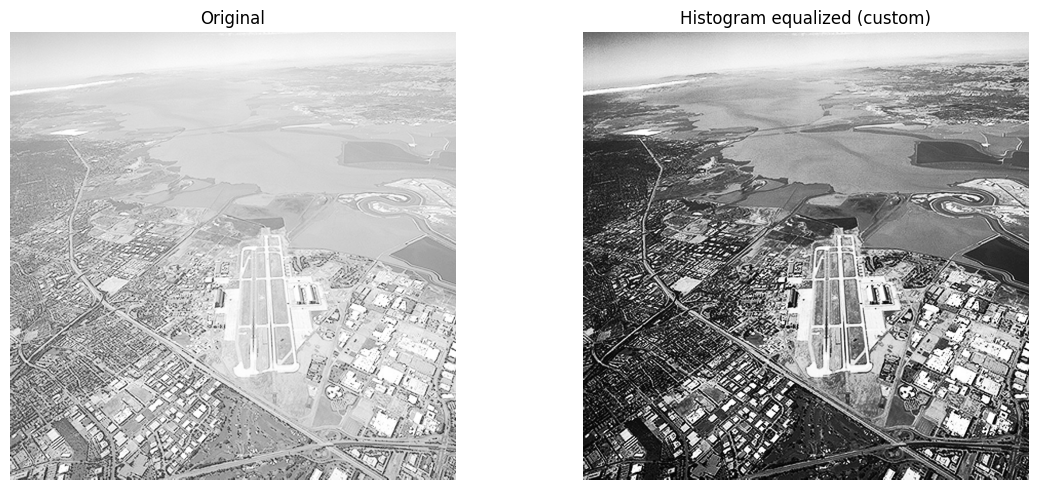

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(q3_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(g_3,   cmap='gray', vmin=0, vmax=255); ax[1].set_title('Histogram equalized (custom)'); ax[1].axis('off')
plt.tight_layout()
plt.show()

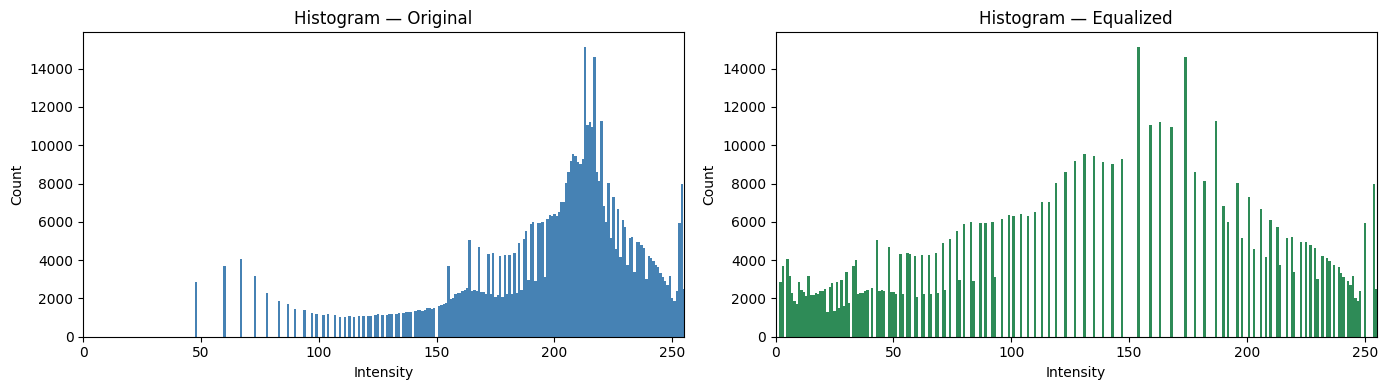

In [6]:
# Compute histogram of the equalized output too
hist_out = np.array([np.sum(g_3 == k) for k in range(256)])

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].bar(np.arange(256), hist_3, color='steelblue', width=1.0)
ax[0].set_xlim(0, 255); ax[0].set_title('Histogram — Original')
ax[0].set_xlabel('Intensity'); ax[0].set_ylabel('Count')

ax[1].bar(np.arange(256), hist_out, color='seagreen', width=1.0)
ax[1].set_xlim(0, 255); ax[1].set_title('Histogram — Equalized')
ax[1].set_xlabel('Intensity'); ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

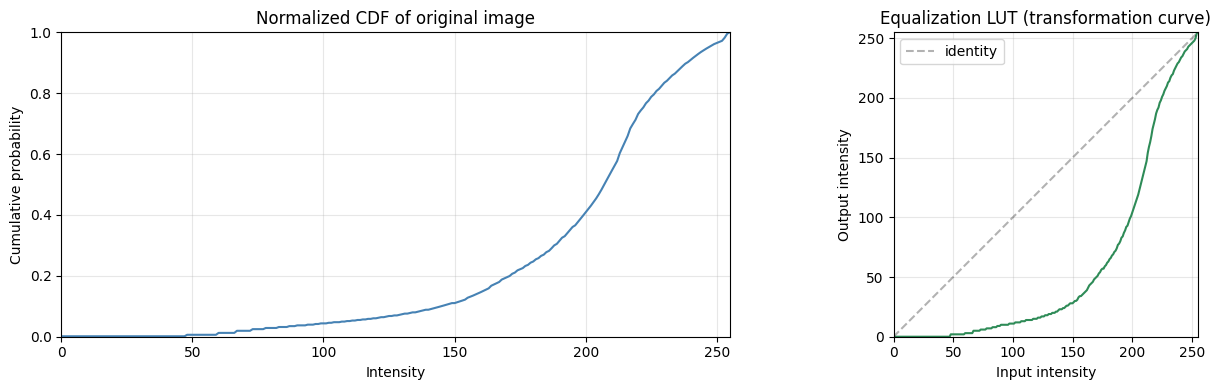

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Normalized CDF of the original
ax[0].plot(np.arange(256), cdf_3 / cdf_3[-1], color='steelblue')
ax[0].set_xlim(0, 255); ax[0].set_ylim(0, 1)
ax[0].set_title('Normalized CDF of original image')
ax[0].set_xlabel('Intensity'); ax[0].set_ylabel('Cumulative probability')
ax[0].grid(alpha=0.3)

# The LUT (transformation curve)
ax[1].plot(np.arange(256), t_3, color='seagreen')
ax[1].plot([0, 255], [0, 255], 'k--', alpha=0.3, label='identity')
ax[1].set_xlim(0, 255); ax[1].set_ylim(0, 255)
ax[1].set_title('Equalization LUT (transformation curve)')
ax[1].set_xlabel('Input intensity'); ax[1].set_ylabel('Output intensity')
ax[1].grid(alpha=0.3); ax[1].legend(); ax[1].set_aspect('equal')

plt.tight_layout()
plt.show()

Max pixel difference between custom and OpenCV: 1
Mean pixel difference: 0.1693


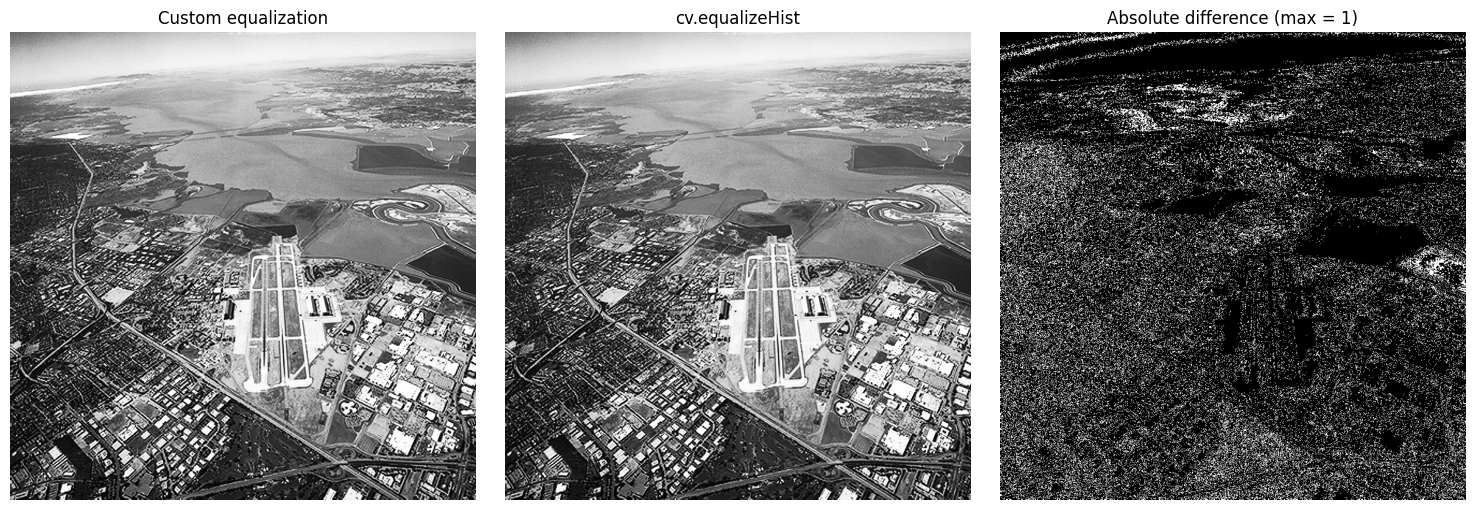

In [8]:
# Sanity check: compare with cv.equalizeHist
g_cv = cv.equalizeHist(q3_im)

# Difference map
diff = cv.absdiff(g_3, g_cv)
print(f'Max pixel difference between custom and OpenCV: {diff.max()}')
print(f'Mean pixel difference: {diff.mean():.4f}')

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(g_3,  cmap='gray', vmin=0, vmax=255); ax[0].set_title('Custom equalization'); ax[0].axis('off')
ax[1].imshow(g_cv, cmap='gray', vmin=0, vmax=255); ax[1].set_title('cv.equalizeHist'); ax[1].axis('off')
ax[2].imshow(diff, cmap='gray'); ax[2].set_title(f'Absolute difference (max = {diff.max()})'); ax[2].axis('off')
plt.tight_layout()
plt.show()